# GPR Index EDA
This notebook will be for exploratory data analysis on the [global political risk index](https://www.matteoiacoviello.com/gpr.htm).


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Configuration
START_DATE = "2018-01-01"
END_DATE = "2025-01-01"
print(f"Date Range: {START_DATE} → {END_DATE}")

path = "../data/gpr_index.csv"

Date Range: 2018-01-01 → 2025-01-01


In [2]:
# Getting our data :)
df = pd.read_csv(path)

# Lets get our desired columns
gpr_index = df[["month", "GPR"]].copy()
gpr_index["month"] = pd.to_datetime(gpr_index["month"], format="%d/%m/%Y")
gpr_index = gpr_index[(gpr_index["month"] >= START_DATE) & (gpr_index["month"] <= END_DATE)]

# Summary
print(gpr_index)

          month     GPR
1416 2018-01-01   92.43
1417 2018-02-01   64.49
1418 2018-03-01  111.96
1419 2018-04-01  123.26
1420 2018-05-01  125.67
...         ...     ...
1496 2024-09-01  130.36
1497 2024-10-01  130.69
1498 2024-11-01  128.90
1499 2024-12-01  142.37
1500 2025-01-01  113.23

[85 rows x 2 columns]


So now we have the dataframe of the GPR index by month from our desired start to end date range.
Lets investigate the data quality.

In [3]:
print("=== Data Quality Report ===")

print(f"Shape:          {gpr_index.shape}")
print(f"Date Range:     {gpr_index['month'].min().date()} → {gpr_index['month'].max().date()}")
print(f"Missing Values: Month Missing: {gpr_index['month'].isna().sum()}, GPR Missing: {gpr_index['GPR'].isna().sum()}")
print()

print("=== Descriptive Statistics ===")
print(f"Mean:           {gpr_index['GPR'].mean():.2f}")
print(f"Median:         {gpr_index['GPR'].median():.2f}")
print(f"Std Dev:        {gpr_index['GPR'].std():.2f}")
print(f"Skewness:       {gpr_index['GPR'].skew():.2f}")
print(f"Kurtosis:       {gpr_index['GPR'].kurtosis():.2f}")
print(f"Min:            {gpr_index['GPR'].min():.2f}")
print(f"Max:            {gpr_index['GPR'].max():.2f}")

q1 = gpr_index['GPR'].quantile(0.25)
q3 = gpr_index['GPR'].quantile(0.75)
iqr = q3 - q1

print(f"Q1 (25th):      {q1:.2f}")
print(f"Q3 (75th):      {q3:.2f}")
print(f"IQR:            {iqr:.2f}")
print(f"Upper Fence:    {q3 + 1.5 * iqr:.2f}")
print(f"Outliers:       {(gpr_index['GPR'] > q3 + 1.5 * iqr).sum()}")

=== Data Quality Report ===
Shape:          (85, 2)
Date Range:     2018-01-01 → 2025-01-01
Missing Values: Month Missing: 0, GPR Missing: 0

=== Descriptive Statistics ===
Mean:           109.00
Median:         104.27
Std Dev:        39.07
Skewness:       2.30
Kurtosis:       9.31
Min:            58.42
Max:            318.95
Q1 (25th):      80.41
Q3 (75th):      130.36
IQR:            49.95
Upper Fence:    205.29
Outliers:       2


## Exploratory Data Analysis


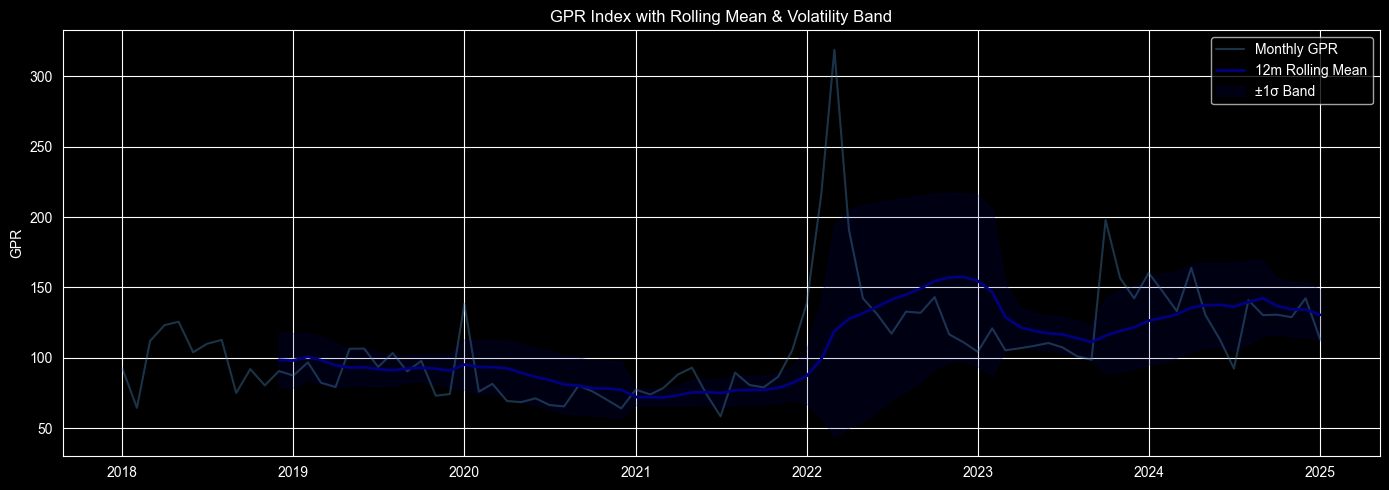

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gpr_index["month"], gpr_index["GPR"], alpha=0.4, label="Monthly GPR", color="steelblue")
rolling = gpr_index["GPR"].rolling(12)
ax.plot(gpr_index["month"], rolling.mean(), label="12m Rolling Mean", color="navy", linewidth=2)
ax.fill_between(gpr_index["month"],
                rolling.mean() - rolling.std(),
                rolling.mean() + rolling.std(),
                alpha=0.15, color="navy", label="±1σ Band")
ax.set_title("GPR Index with Rolling Mean & Volatility Band")
ax.legend()
ax.set_ylabel("GPR")
plt.tight_layout()
plt.show()

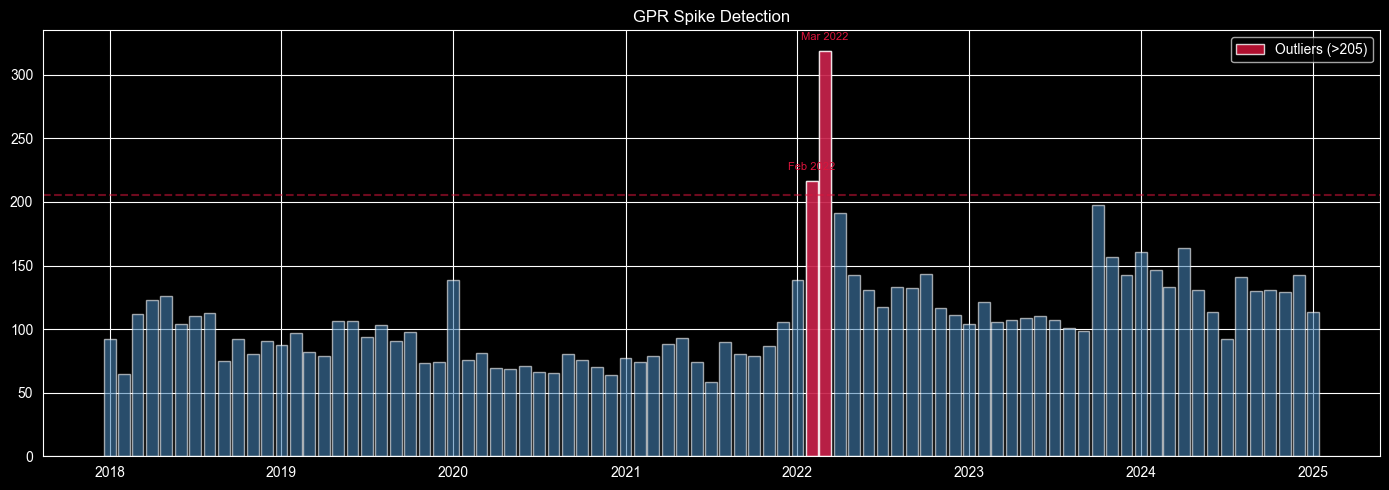

In [5]:
q1 = gpr_index["GPR"].quantile(0.25)
q3 = gpr_index["GPR"].quantile(0.75)
fence = q3 + 1.5 * (q3 - q1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(gpr_index["month"], gpr_index["GPR"], width=25, color="steelblue", alpha=0.6)
spikes = gpr_index[gpr_index["GPR"] > fence]
ax.bar(spikes["month"], spikes["GPR"], width=25, color="crimson", alpha=0.8, label=f"Outliers (>{fence:.0f})")
for _, row in spikes.iterrows():
    ax.annotate(row["month"].strftime("%b %Y"), (row["month"], row["GPR"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8, color="crimson")
ax.axhline(fence, ls="--", color="crimson", alpha=0.5)
ax.set_title("GPR Spike Detection")
ax.legend()
plt.tight_layout()
plt.show()

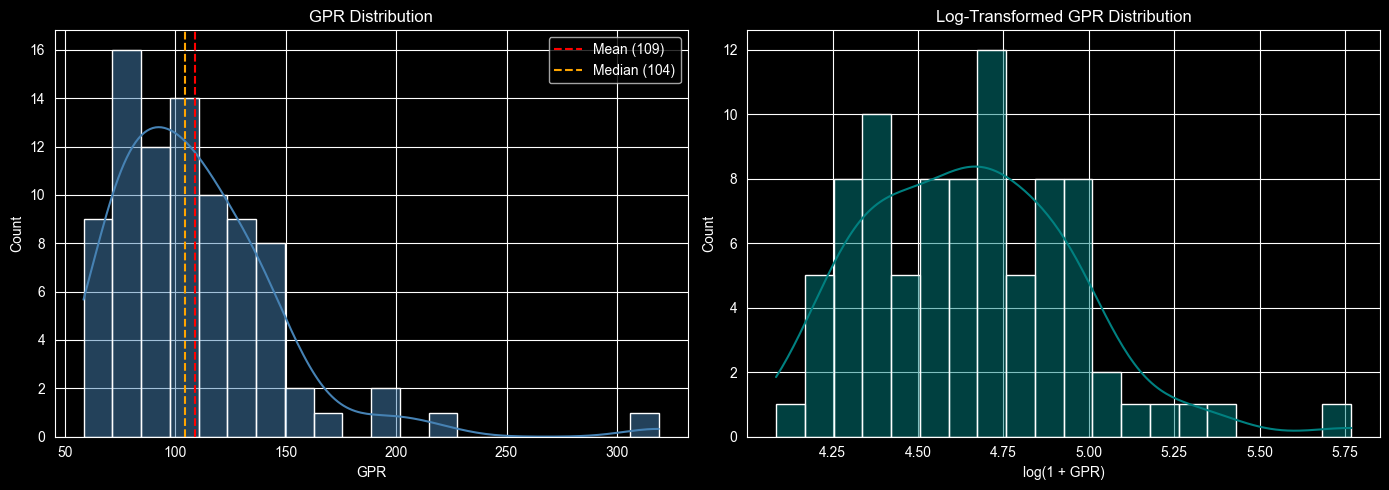

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(gpr_index["GPR"], kde=True, bins=20, ax=axes[0], color="steelblue")
axes[0].axvline(gpr_index["GPR"].mean(), ls="--", color="red", label=f"Mean ({gpr_index['GPR'].mean():.0f})")
axes[0].axvline(gpr_index["GPR"].median(), ls="--", color="orange", label=f"Median ({gpr_index['GPR'].median():.0f})")
axes[0].legend()
axes[0].set_title("GPR Distribution")

sns.histplot(np.log1p(gpr_index["GPR"]), kde=True, bins=20, ax=axes[1], color="teal")
axes[1].set_title("Log-Transformed GPR Distribution")
axes[1].set_xlabel("log(1 + GPR)")

plt.tight_layout()
plt.show()

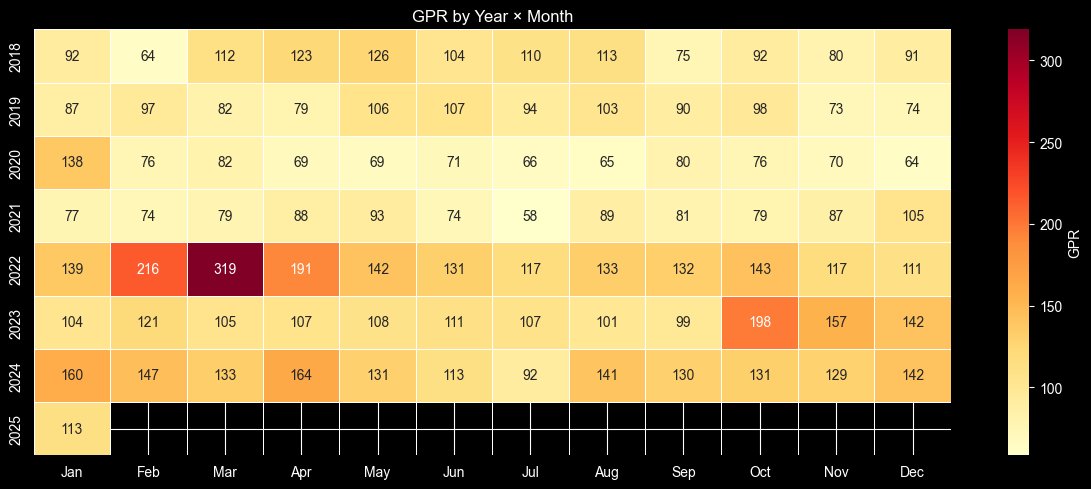

In [7]:
heat = gpr_index.copy()
heat["year"] = heat["month"].dt.year
heat["mo"] = heat["month"].dt.month
pivot = heat.pivot_table(index="year", columns="mo", values="GPR")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5, ax=ax, cbar_kws={"label": "GPR"})
ax.set_title("GPR by Year × Month")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

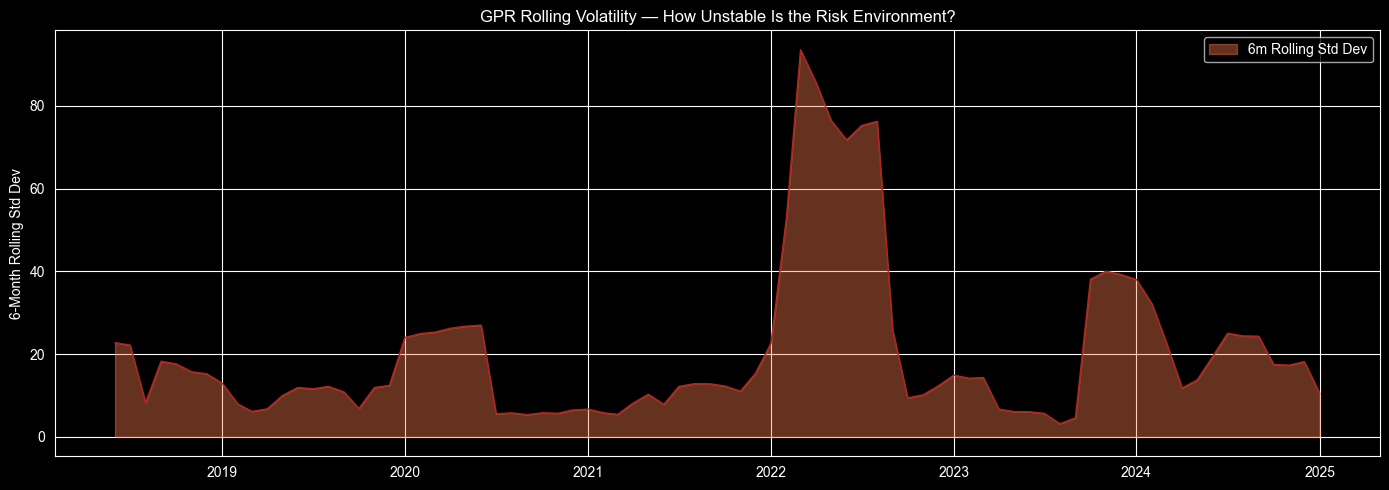

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
vol = gpr_index["GPR"].rolling(6).std()
ax.fill_between(gpr_index["month"], vol, alpha=0.4, color="coral", label="6m Rolling Std Dev")
ax.plot(gpr_index["month"], vol, color="firebrick", linewidth=1)
ax.set_title("GPR Rolling Volatility — How Unstable Is the Risk Environment?")
ax.set_ylabel("6-Month Rolling Std Dev")
ax.legend()
plt.tight_layout()
plt.show()

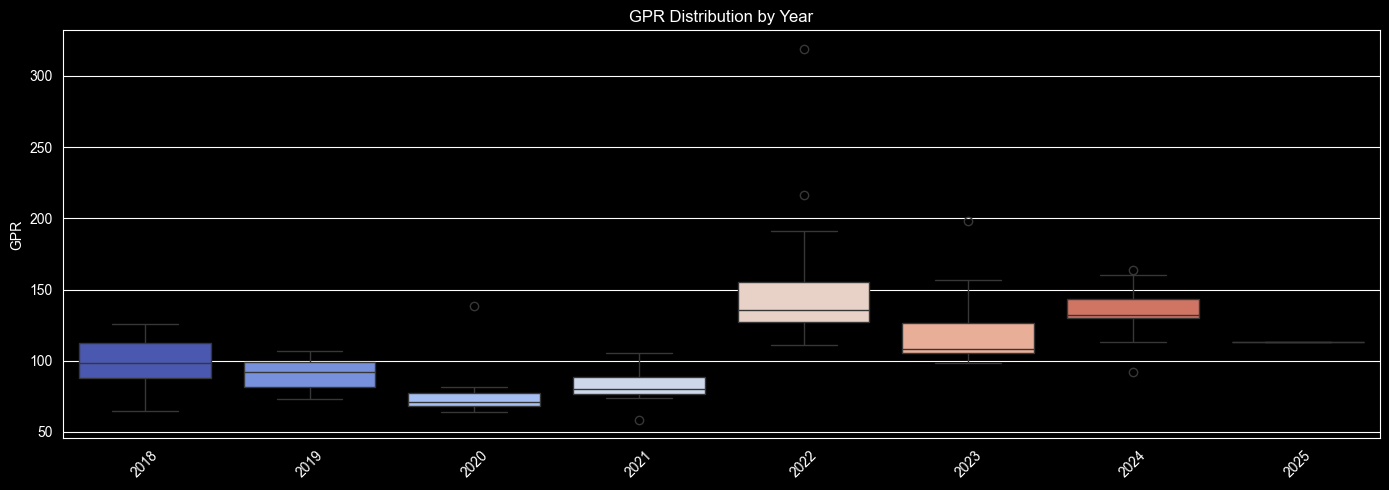

In [9]:
box = gpr_index.copy()
box["year"] = box["month"].dt.year

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=box, x="year", y="GPR", hue="year", palette="coolwarm", legend=False, ax=ax)
ax.set_title("GPR Distribution by Year")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

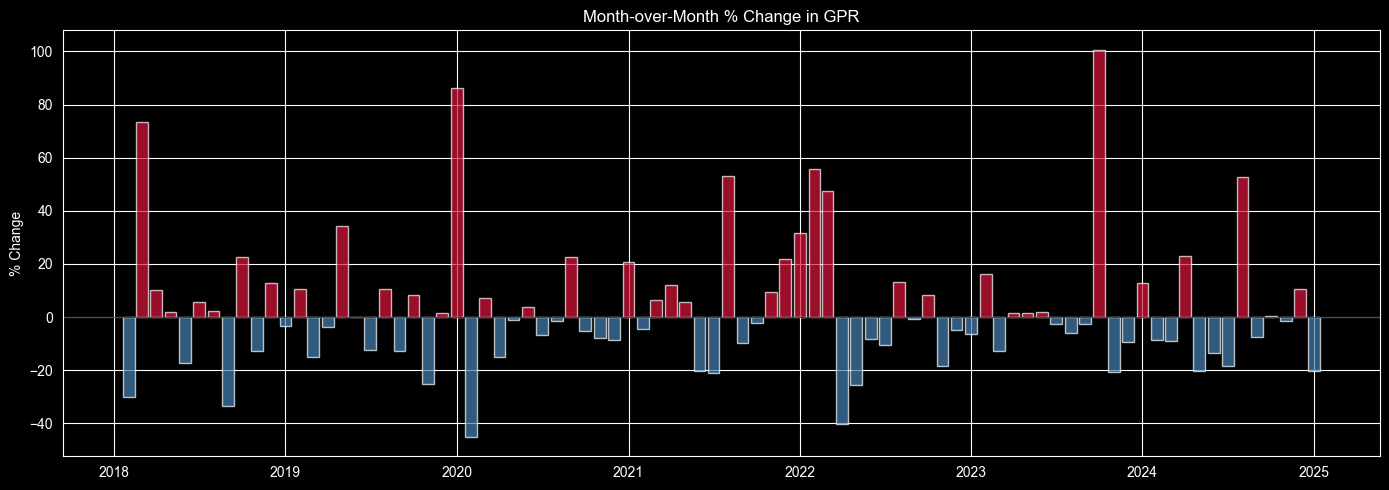

In [10]:
gpr_index["mom_change"] = gpr_index["GPR"].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["crimson" if x > 0 else "steelblue" for x in gpr_index["mom_change"]]
ax.bar(gpr_index["month"], gpr_index["mom_change"], color=colors, width=25, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Month-over-Month % Change in GPR")
ax.set_ylabel("% Change")
plt.tight_layout()
plt.show()

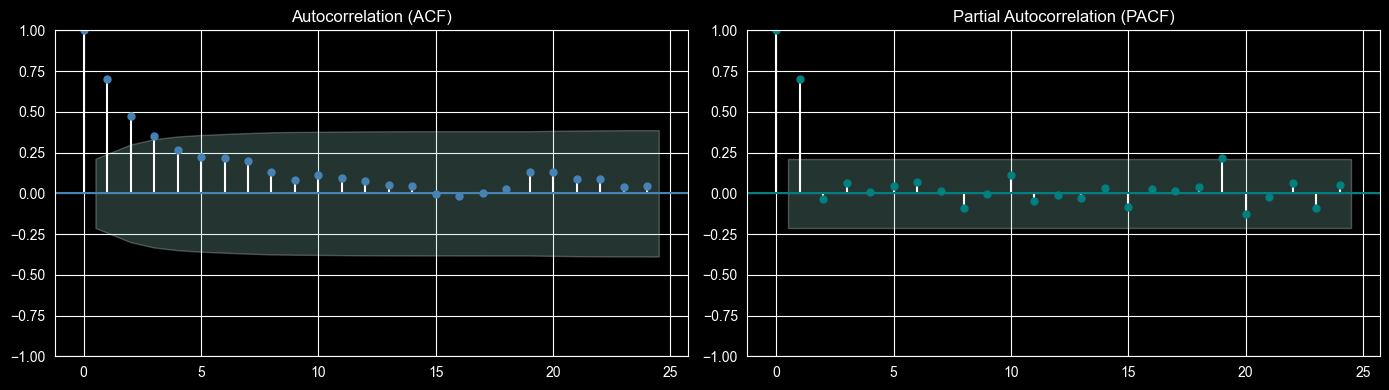

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sm.graphics.tsa.plot_acf(gpr_index["GPR"].dropna(), lags=24, ax=axes[0], color="steelblue")
axes[0].set_title("Autocorrelation (ACF)")
sm.graphics.tsa.plot_pacf(gpr_index["GPR"].dropna(), lags=24, ax=axes[1], color="teal")
axes[1].set_title("Partial Autocorrelation (PACF)")
plt.tight_layout()
plt.show()

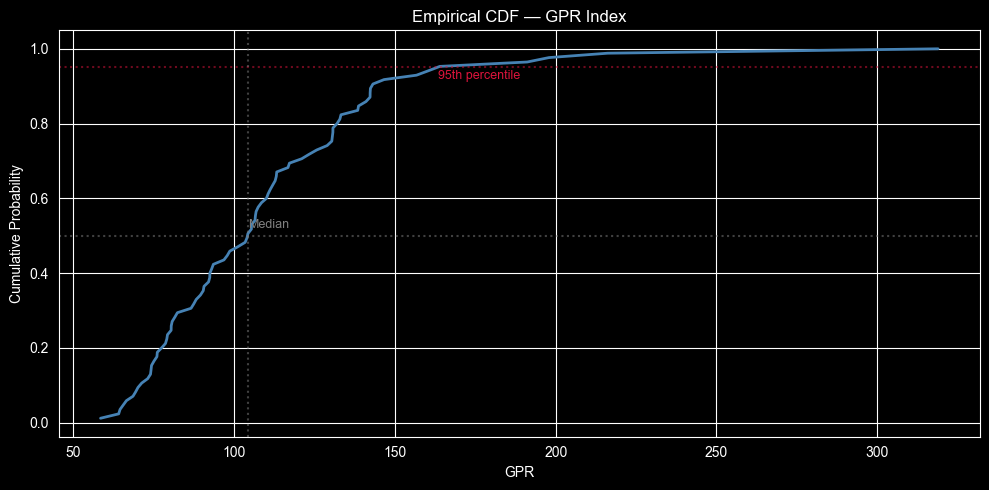

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sorted_gpr = np.sort(gpr_index["GPR"].dropna())
cdf = np.arange(1, len(sorted_gpr) + 1) / len(sorted_gpr)
ax.plot(sorted_gpr, cdf, color="steelblue", linewidth=2)
ax.axhline(0.5, ls=":", color="gray", alpha=0.5)
ax.axhline(0.95, ls=":", color="crimson", alpha=0.5)
ax.axvline(gpr_index["GPR"].median(), ls=":", color="gray", alpha=0.5)
ax.annotate("Median", (gpr_index["GPR"].median(), 0.52), fontsize=9, color="gray")
ax.annotate("95th percentile", (gpr_index["GPR"].quantile(0.95), 0.92), fontsize=9, color="crimson")
ax.set_title("Empirical CDF — GPR Index")
ax.set_xlabel("GPR")
ax.set_ylabel("Cumulative Probability")
plt.tight_layout()
plt.show()

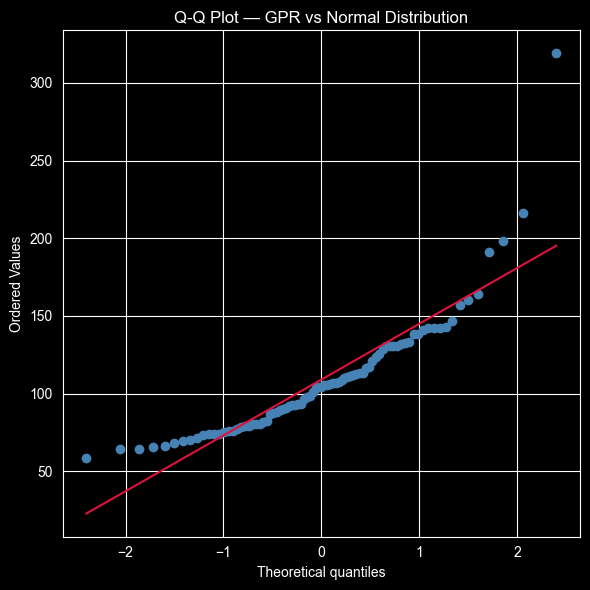

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(gpr_index["GPR"].dropna(), dist="norm", plot=ax)
ax.set_title("Q-Q Plot — GPR vs Normal Distribution")
ax.get_lines()[0].set_color("steelblue")
ax.get_lines()[1].set_color("crimson")
plt.tight_layout()
plt.show()